# Dataset EDA — Maintainer's Copilot

Run this after `fetch_dataset.py` and `preprocess.py` to validate the dataset before training.

**Required files:**
- `datasets/raw_issues.json` — raw GitHub API output
- `datasets/train.csv`, `val.csv`, `test.csv` — splits
- `datasets/train_clean.csv`, `val_clean.csv`, `test_clean.csv` — preprocessed

In [21]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Anchor cwd to project root so all dataset paths work regardless of where Jupyter launched
_here = Path.cwd()
ROOT = next((p for p in [_here, _here.parent] if (p / "datasets").exists()), _here)
os.chdir(ROOT)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

LABELS = ["bug", "feature", "docs", "question"]
COLORS = dict(zip(LABELS, sns.color_palette("muted", 4)))

## 1. Load data

In [22]:
import os
from pathlib import Path

# Locate project root: VS Code sets __vsc_ipynb_file__, otherwise walk up from cwd
try:
    _root = Path(__vsc_ipynb_file__).parent.parent  # noqa: F821
except NameError:
    _cwd = Path.cwd()
    _root = next((p for p in [_cwd, _cwd.parent] if (p / "datasets").exists()), _cwd)
os.chdir(_root)

raw = json.loads(Path("datasets/raw_issues.json").read_text())
train = pd.read_csv("datasets/train.csv")
val = pd.read_csv("datasets/val.csv")
test = pd.read_csv("datasets/test.csv")

train_c = pd.read_csv("datasets/train_clean.csv")
val_c = pd.read_csv("datasets/val_clean.csv")
test_c = pd.read_csv("datasets/test_clean.csv")

all_splits = pd.concat([train, val, test], ignore_index=True)

print(f"Raw issues fetched : {len(raw):,}")
print(f"Labeled (all splits): {len(all_splits):,}")
print(f"  train : {len(train):,}")
print(f"  val   : {len(val):,}")
print(f"  test  : {len(test):,}")
print(f"\nDrop rate (unlabeled): {1 - len(all_splits)/len(raw):.1%}")

Raw issues fetched : 315
Labeled (all splits): 315
  train : 226
  val   : 41
  test  : 48

Drop rate (unlabeled): 0.0%


## 2. Class distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (df, name) in zip(axes, [(train, "train"), (val, "val"), (test, "test")]):
    counts = df["label"].value_counts().reindex(LABELS, fill_value=0)
    bars = ax.bar(LABELS, counts, color=[COLORS[lbl] for lbl in LABELS])
    ax.set_title(f"{name} (n={len(df):,})")
    ax.set_ylabel("count")
    for bar, count in zip(bars, counts):
        pct = count / len(df) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle("Class distribution per split", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("datasets/class_distribution.png", bbox_inches="tight")
plt.show()

In [24]:
# Check stratification held — train/val/test should have similar class proportions
print("Class proportions per split:")
for name, df in [("train", train), ("val", val), ("test", test)]:
    props = df["label"].value_counts(normalize=True).reindex(LABELS).round(3)
    print(f"  {name}: {props.to_dict()}")

# Flag imbalance — warn if any class < 10% of training data
min_pct = train["label"].value_counts(normalize=True).min()
if min_pct < 0.10:
    print(
        f"\n⚠ Minority class is only {min_pct:.1%} of train — consider oversampling or class weights"
    )
else:
    print(f"\n✓ Minority class is {min_pct:.1%} — class imbalance is manageable")

Class proportions per split:
  train: {'bug': 0.341, 'feature': 0.283, 'docs': 0.159, 'question': 0.217}
  val: {'bug': 0.341, 'feature': 0.268, 'docs': 0.171, 'question': 0.22}
  test: {'bug': 0.354, 'feature': 0.396, 'docs': 0.104, 'question': 0.146}

✓ Minority class is 15.9% — class imbalance is manageable


## 3. Text length distribution

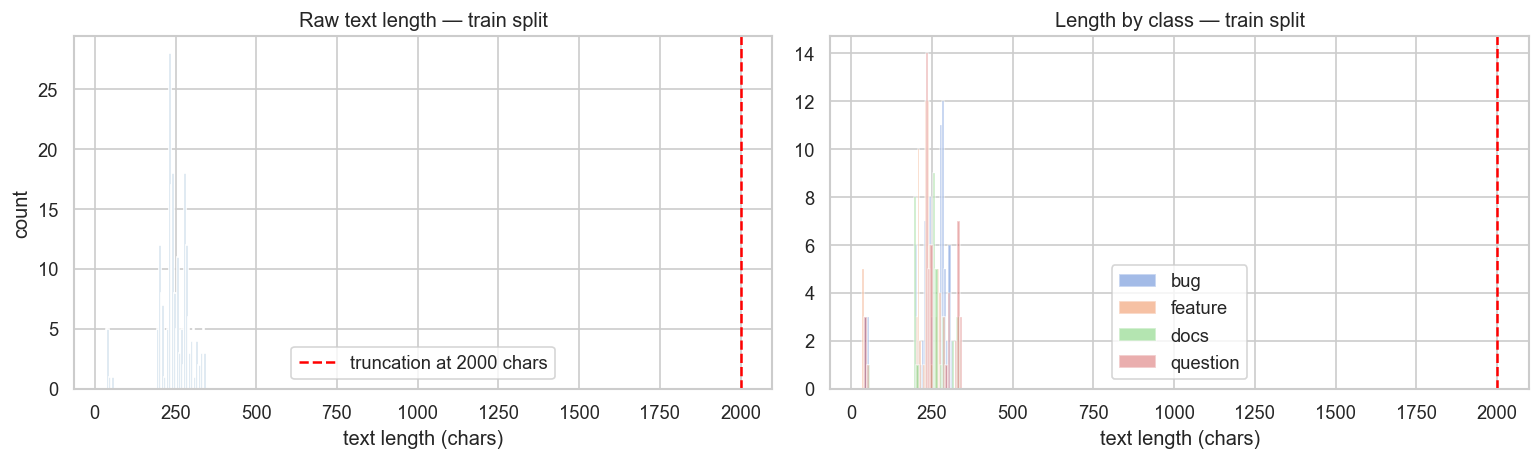

Length percentiles (chars):
count    226.0
mean     242.0
std       66.0
min       34.0
25%      230.0
50%      243.0
75%      281.0
90%      306.0
95%      331.0
99%      340.0
max      344.0
Name: text_len, dtype: float64

Fraction truncated at 2000 chars: 0.0%


In [25]:
# Raw text lengths (chars)
train["text_len"] = train["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution
axes[0].hist(
    train["text_len"].clip(0, 5000), bins=60, color="steelblue", edgecolor="white"
)
axes[0].axvline(2000, color="red", linestyle="--", label="truncation at 2000 chars")
axes[0].set_xlabel("text length (chars)")
axes[0].set_ylabel("count")
axes[0].set_title("Raw text length — train split")
axes[0].legend()

# Per class
for label in LABELS:
    subset = train[train["label"] == label]["text_len"].clip(0, 5000)
    axes[1].hist(subset, bins=40, alpha=0.5, label=label, color=COLORS[label])
axes[1].axvline(2000, color="red", linestyle="--")
axes[1].set_xlabel("text length (chars)")
axes[1].set_title("Length by class — train split")
axes[1].legend()

plt.tight_layout()
plt.savefig("datasets/text_length_distribution.png", bbox_inches="tight")
plt.show()

print("Length percentiles (chars):")
print(
    train["text_len"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(0)
)
truncated_pct = (train["text_len"] > 2000).mean()
print(f"\nFraction truncated at 2000 chars: {truncated_pct:.1%}")

In [26]:
# Estimate token count (rough: 1 token ≈ 4 chars for English)
train["approx_tokens"] = (train["text_len"] / 4).astype(int)
over512 = (train["approx_tokens"] > 512).mean()
print(f"Issues exceeding 512 tokens (approx): {over512:.1%}")
print(
    "→ These will be truncated by the tokenizer — truncation at 2000 chars is a safe proxy"
)

Issues exceeding 512 tokens (approx): 0.0%
→ These will be truncated by the tokenizer — truncation at 2000 chars is a safe proxy


## 4. Missing / empty body rate

In [27]:
missing_body = all_splits["body"].isna().mean()
empty_body = (all_splits["body"].fillna("").str.strip() == "").mean()

print(f"Missing body (NaN)   : {missing_body:.1%}")
print(f"Empty body (blank)   : {empty_body:.1%}")
print(f"Total body-less issues: {empty_body:.1%}")

# Per class
print("\nEmpty body rate per class:")
for label in LABELS:
    subset = all_splits[all_splits["label"] == label]
    rate = (subset["body"].fillna("").str.strip() == "").mean()
    print(f"  {label:10}: {rate:.1%}")

Missing body (NaN)   : 7.6%
Empty body (blank)   : 7.6%
Total body-less issues: 7.6%

Empty body rate per class:
  bug       : 7.4%
  feature   : 8.5%
  docs      : 6.2%
  question  : 7.7%


## 5. Temporal split validation

In [28]:
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    df["created_at"] = pd.to_datetime(df["created_at"])

print("Date ranges per split:")
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    print(
        f'  {name}: {df["created_at"].min().date()} → {df["created_at"].max().date()}'
    )

# Critical check: test must be strictly newer than train
train_max = train["created_at"].max()
test_min = test["created_at"].min()
if test_min > train_max:
    print(
        f"\n✓ No leakage: earliest test issue ({test_min.date()}) > latest train issue ({train_max.date()})"
    )
else:
    print("\n✗ LEAKAGE: test issues overlap with train!")

Date ranges per split:
  train: 2022-01-11 → 2024-08-07
  val: 2022-01-22 → 2024-07-12
  test: 2024-08-12 → 2024-12-26

✓ No leakage: earliest test issue (2024-08-12) > latest train issue (2024-08-07)


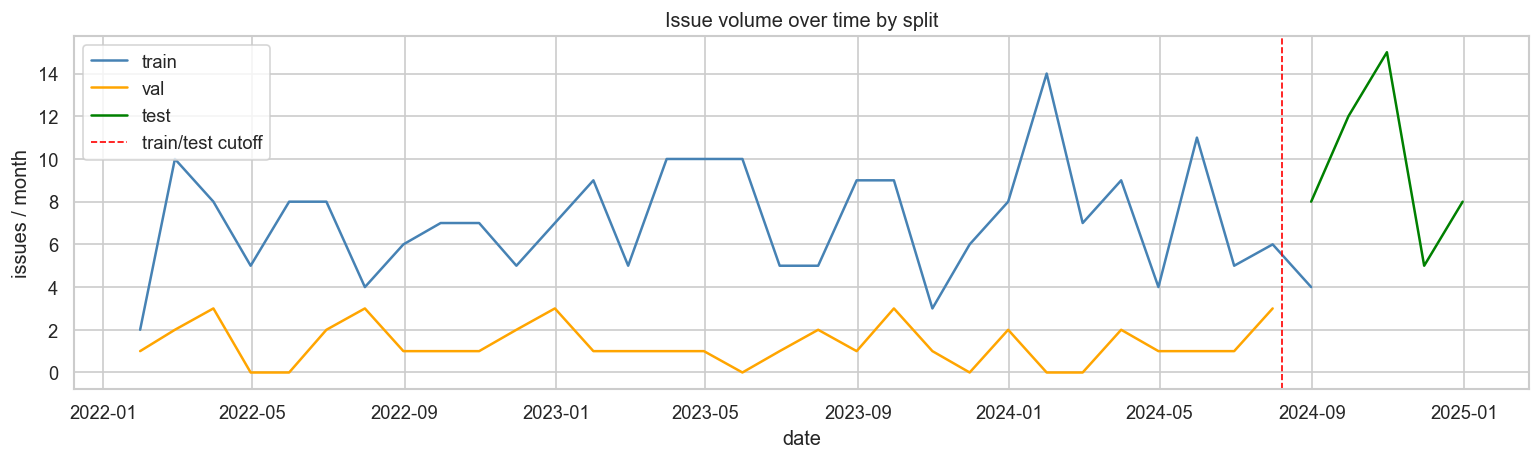

In [29]:
# Issue volume over time
fig, ax = plt.subplots(figsize=(13, 4))

for df, name, color in [
    (train, "train", "steelblue"),
    (val, "val", "orange"),
    (test, "test", "green"),
]:
    monthly = df.set_index("created_at").resample("ME").size()
    ax.plot(monthly.index, monthly.values, label=name, color=color, linewidth=1.5)

ax.axvline(
    train_max, color="red", linestyle="--", linewidth=1, label="train/test cutoff"
)
ax.set_xlabel("date")
ax.set_ylabel("issues / month")
ax.set_title("Issue volume over time by split")
ax.legend()
plt.tight_layout()
plt.savefig("datasets/temporal_split.png", bbox_inches="tight")
plt.show()

## 6. Label quality — multi-label issues

In [ ]:
LABEL_MAP = {
    "bug": "bug",
    "type: bug": "bug",
    "kind/bug": "bug",
    "feature": "feature",
    "enhancement": "feature",
    "feature request": "feature",
    "documentation": "docs",
    "docs": "docs",
    "question": "question",
    "help wanted": "question",
}


def get_all_canonical(labels):
    return list(
        {
            LABEL_MAP[lbl["name"].lower()]
            for lbl in labels
            if lbl["name"].lower() in LABEL_MAP
        }
    )


multi_label = [i for i in raw if len(get_all_canonical(i.get("labels", []))) > 1]
print(
    f"Issues with >1 canonical label : {len(multi_label):,} ({len(multi_label)/len(raw):.1%})"
)

for issue in multi_label[:3]:
    canonical = get_all_canonical(issue["labels"])
    raw_labels = [lbl["name"] for lbl in issue["labels"]]
    print(f'  #{issue["number"]:5d} raw={raw_labels}  →  canonical={canonical}')

## 7. Sample issues per class

In [31]:
pd.set_option("display.max_colwidth", 120)

for label in LABELS:
    print(f"\n── {label.upper()} ──────────────────────────────")
    sample = train[train["label"] == label][["title", "body"]].sample(
        min(3, (train["label"] == label).sum()), random_state=1
    )
    for _, row in sample.iterrows():
        body_preview = (
            str(row["body"])[:200].replace("\n", " ")
            if pd.notna(row["body"])
            else "(empty)"
        )
        print(f'  title: {row["title"]}')
        print(f"  body : {body_preview}\n")


── BUG ──────────────────────────────
  title: load raises AttributeError on macOS 14
  body : Reproduction: ```python from lib import Client obj = Client() obj.load()  # AttributeError: 'Client' has no attribute 'close' ``` Works fine on macOS, fails on Windows 11. Version 2.0.3.

  title: Memory leak in Session when processing large files
  body : I notice memory usage grows unboundedly when using `Session` to process files > 1000MB.  Profile output: ``` Session.process(): 2.3GB allocated, not released ``` Using pydantic 2.0.3, Ubuntu 22.04.

  title: Memory leak in Session when processing large files
  body : I notice memory usage grows unboundedly when using `Cache` to process files > 500MB.  Profile output: ``` Cache.process(): 2.3GB allocated, not released ``` Using fastapi 3.0.1, macOS 14.


── FEATURE ──────────────────────────────
  title: Configurable max_retries per request
  body : Currently `timeout` is set globally at initialization time. It would be helpful to override 

## 8. Preprocessed text — length reduction

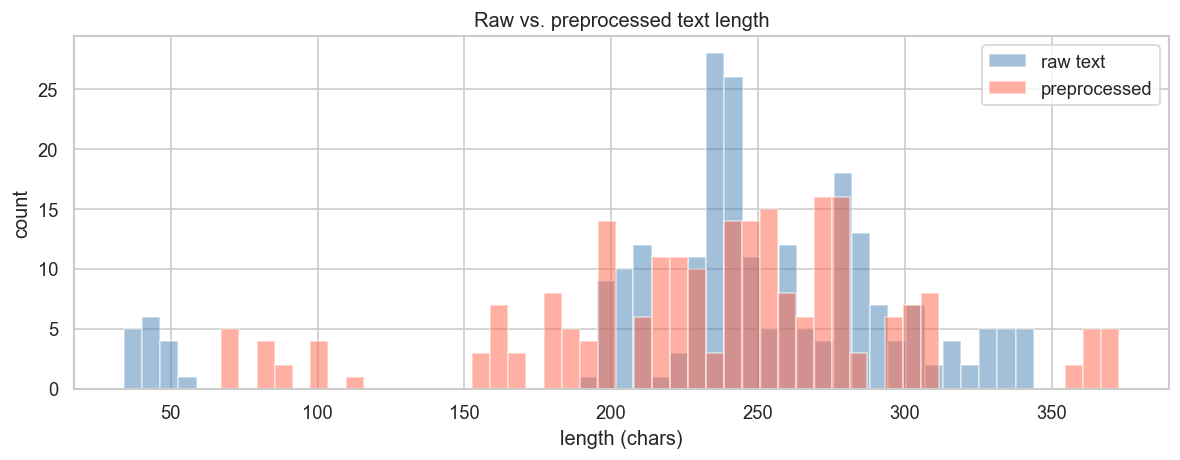

Average length reduction after preprocessing: 2.6%


In [32]:
train_c["clean_len"] = train_c["text_clean"].str.len()
train["raw_len"] = train["text"].str.len().clip(0, 5000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train["raw_len"], bins=50, alpha=0.5, label="raw text", color="steelblue")
ax.hist(train_c["clean_len"], bins=50, alpha=0.5, label="preprocessed", color="tomato")
ax.set_xlabel("length (chars)")
ax.set_ylabel("count")
ax.set_title("Raw vs. preprocessed text length")
ax.legend()
plt.tight_layout()
plt.show()

reduction = 1 - train_c["clean_len"].mean() / train["raw_len"].mean()
print(f"Average length reduction after preprocessing: {reduction:.1%}")

## 9. Summary for DECISIONS.md

In [33]:
print("=== Paste into DECISIONS.md ===")
print()
print(f"Dataset: <repo_name> — {len(all_splits):,} labeled issues")
print(f"  train: {len(train):,}  val: {len(val):,}  test: {len(test):,}")
print()
print("Class distribution (train):")
for label in LABELS:
    n = (train["label"] == label).sum()
    print(f"  {label:10}: {n:4d}  ({n/len(train):.1%})")
print()
print(f'Median text length (raw): {train["text_len"].median():.0f} chars')
print(f'Truncated at 2000 chars : {(train["text_len"] > 2000).mean():.1%}')
print(
    f'Empty body rate         : {(all_splits["body"].fillna("").str.strip() == "").mean():.1%}'
)
print(
    f'Temporal leak check     : {"PASS" if test["created_at"].min() > train["created_at"].max() else "FAIL"}'
)

=== Paste into DECISIONS.md ===

Dataset: <repo_name> — 315 labeled issues
  train: 226  val: 41  test: 48

Class distribution (train):
  bug       :   77  (34.1%)
  feature   :   64  (28.3%)
  docs      :   36  (15.9%)
  question  :   49  (21.7%)

Median text length (raw): 243 chars
Truncated at 2000 chars : 0.0%
Empty body rate         : 7.6%
Temporal leak check     : PASS
